In [14]:
import seaborn as sns

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif"}
sns.set_theme(context = "talk", style="ticks", rc=custom_params) 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from typing import List, Tuple
import os
import json
import re
from matplotlib.cm import viridis
from matplotlib.colors import Normalize, LogNorm

import parameters

# Extraction functions

In [16]:
def parse_config(path: str) -> Tuple[List[np.ndarray], int]:
    """
    Parses .config files containing trajectories of particlrs in suspension at each time step.
    Arguments : 
        path, the path to the config file.
    Returns : 
        frames, lists of arrays of positions per time step.
        n_expected, the number of expected separate trajectorires.
    """
    frames: List[np.ndarray] = []
    n_expected = None

    with open(path, "r", encoding="utf-8") as f:
        lines = (ln.strip() for ln in f)
        while True:
            for ln in lines:
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) == 1 and parts[0].lstrip("-").isdigit():
                    n = int(parts[0])
                    if n <= 0:
                        raise ValueError(f"Invalid particle count: {n}")
                    if n_expected is None:
                        n_expected = n
                    elif n_expected != n:
                        raise ValueError(f"Inconsistent particle count: {n} (expected {n_expected})")
                    break
                else:
                    raise ValueError(f"Expected particle count line, got: {ln}")
            else:
                break 

            xyz = []
            for _ in range(n):
                try:
                    ln = next(lines).strip()
                except StopIteration:
                    raise ValueError("Unexpected EOF inside a timestep.")
                vals = ln.split()
                x, y, z = map(float, vals[:3])
                xyz.append((x, y, z))
            frames.append(np.asarray(xyz, dtype=float))
    return frames, n_expected





def frames_to_trajectories(frames: List[np.ndarray]) -> List[np.ndarray]:
    """
    Generates full trajectories from the frames.
    frames: list of arrays shaped (n,3) for each timestep.
    return: list of trajectories, each shaped (T,3), one per particle.
    """
    if not frames:
        raise ValueError("Where frames ???")
    n = frames[0].shape[0]
    arr = np.stack(frames, axis=0)  # (T, n, 3)
    return [arr[:, i, :] for i in range(n)]  # N [(T,3)]




# dedrifting

In [17]:
import numpy as np
from typing import List

def dedrift_shear_x(
    trajs: List[np.ndarray],
    dt: float,
    gamma_dot: float,
    return_full: bool = False
) -> List[np.ndarray]:
    
    """Calculates the mean drift a single particle will feel at a single time step and subtraxts it.
    Reconstructs the final trajectory without the shear. """

    if not trajs:
        return []

    out = []
    for tr in trajs:
        tr = np.asarray(tr, dtype=float)
        if tr.ndim != 2 or tr.shape[1] < 3:
            # if nothing to correct
            out.append(tr if return_full else tr[..., 0])
            continue

        x = tr[:, 0] #nothing to see along y
        z = tr[:, 2]

        if x.size < 2:
            # if nothing to diff/cumsum
            if return_full:
                out.append(tr.copy())
            else:
                out.append(x.copy())
            continue

        # Midpoint z between frames and dx
        z_mid  = 0.5 * (z[1:] + z[:-1])            
        dx     = x[1:] - x[:-1]                    
        shear_dx = gamma_dot * z_mid * dt          
        dx_corr  = dx - shear_dx                   # drift-removed step

        # Reconstruct corrected x by cumulative sum of corrected steps!
        x_corr = np.empty_like(x)
        x_corr[0]  = x[0]
        x_corr[1:] = x[0] + np.cumsum(dx_corr)

        if return_full:
            tr2 = tr.copy()
            tr2[:, 0] = x_corr
            out.append(tr2)
        else:
            out.append(x_corr)

    return out # 



In [18]:
def get_component_signal(tr, comp):
    if isinstance(tr, dict):
        return np.asarray(tr[comp], dtype=float)
    comp_idx = {'x': 0, 'y': 1, 'z': 2}[comp]
    tr = np.asarray(tr)
    if tr.ndim == 2 and tr.shape[1] >= comp_idx+1:
        return tr[:, comp_idx].astype(float)
    raise ValueError("Unrecognized trajectory format for get_component_signal func")

def compute_average_msd(signals, comp, dt, max_decade=8):
    xs = [get_component_signal(seg, comp).astype(float)
          for seg in signals if len(seg) >= 2]

    N = len(xs)
    if N == 0:
        return np.array([]), np.array([]), np.array([])

    lag_steps = np.hstack([
        np.arange(10**i, 10**(i+1), 10**i) for i in range(max_decade)
    ]).astype(int)

    def msd_fixed(x, lags):
        out = np.full(len(lags), np.nan)
        for j, lag in enumerate(lags):
            if lag < len(x):
                d = x[lag:] - x[:-lag]
                out[j] = np.nanmean(d * d)
        return out

    all_msd = np.vstack([msd_fixed(x, lag_steps) for x in xs])

    mean_msd = np.nanmean(all_msd, axis=0)
    std_msd  = np.nanstd(all_msd, axis=0)
    sem_msd  = std_msd #keep for FWC

    taus = lag_steps * dt
    return taus, mean_msd, sem_msd





In [19]:


def plot_all_segments(signals, comp, dt): #Added xcrossing visualisation 
    plt.figure()

    x1 = get_component_signal(signals[0], "x").astype(float)
    x2 = get_component_signal(signals[1], "x").astype(float)

    n = len(x1)
    x1, x2 = x1[:n], x2[:n]
    d = x1 - x2

    s = np.sign(d)
    idx = np.where((s[:-1] * s[1:]) < 0)[0]

    crossing_times = []
    for i in idx:
        d0, d1 = d[i], d[i + 1]
        f = -d0 / (d1 - d0)
        crossing_times.append((i + f) * dt)


    for seg in signals:
        y = get_component_signal(seg, comp).astype(float)
        t = np.arange(len(y)) * dt
        plt.plot(t, y, alpha=0.8)

    for tc in crossing_times:
        plt.axvline(tc, linestyle="--", alpha=0.7)

    plt.xlabel("t (s)")
    plt.ylabel(f"{comp} (t)")
    plt.tight_layout()
    plt.show()



In [20]:
def plot_two_particle_msd(msd_p1, msd_p2, labels=("Particle 1", "Particle 2"),
                          show_band=True, loglog=True, xlabel=r"Lag time $\tau$ (s)",
                          ylabel=r"MSD($\tau$)"):
    (taus1, mean1, std1) = msd_p1
    (taus2, mean2, std2) = msd_p2

    plt.figure()

    plt.plot(taus1, mean1, label=labels[0])
    if show_band and std1.size:
        plt.fill_between(taus1, mean1 - std1, mean1 + std1, alpha=0.2)

    plt.plot(taus2, mean2, label=labels[1])
    if show_band and std2.size:
        plt.fill_between(taus2, mean2 - std2, mean2 + std2, alpha=0.2)

    if loglog:
        plt.xscale("log")
        plt.yscale("log")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()



def fit_log_msd_window(scales, msd, lower_bound_fit, upper_bound_fit):
    scales = np.asarray(scales, dtype=float)
    msd = np.asarray(msd, dtype=float)
    mask = (scales >= lower_bound_fit) & (scales <= upper_bound_fit) & np.isfinite(msd) & (msd > 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    x_fit = np.log10(scales[mask])
    y_fit = np.log10(msd[mask])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_pred = slope * x_fit + intercept
    residuals = y_fit - y_pred
    dof = len(x_fit) - 2
    if dof <= 0:
        return slope, intercept, np.nan

    residual_std = np.sqrt(np.sum(residuals**2) / dof)
    denom = np.sqrt(np.sum((x_fit - np.mean(x_fit))**2))
    intercept_std = residual_std / denom if denom > 0 else np.nan
    return slope, intercept, intercept_std 

# for 1 single simulation

config = "/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/aatwoparts_evanesce/A(2.500um,2.500um,0.500um)__B(2.000um,1.000um,0.800um)/run_blobs.sphere_array.config"
comp = "y"
dt = parameters.time_step
frames, num_particles = parse_config(config)
trajs = frames_to_trajectories(frames)

signals = np.array(trajs) #BW compty
# plot_all_segments(signals, comp, dt)

signals_p0 = [trajs[0]]
signals_p1 = [trajs[1]]

res0 = compute_average_msd(signals_p0, comp, dt)
res1 = compute_average_msd(signals_p1, comp, dt)

plot_two_particle_msd(
                          res0, res1, 
                          labels=("Particle 1", "Particle 2"),
                          show_band=False, loglog=True, xlabel=r"Lag time $\tau$ (s)",
                          ylabel=r"MSD($\tau$)"
                          )

# print(compute_average_msd(signals[0], dt, max_decade=8))



In [21]:
_B_RE = re.compile(r"__B\(([^)]+)\)$")  # captures inside B(...)

def extract_B_label(folder_name: str) -> str:
    m = _B_RE.search(folder_name)
    if not m:
        return folder_name
    inside = m.group(1)  
    return f"B({inside})"

def compute_two_particle_msd(config_path: Path, comp: str, dt: float):
    frames, num_particles = parse_config(str(config_path))
    trajs = frames_to_trajectories(frames)

    signals_p0 = [trajs[0]]
    signals_p1 = [trajs[1]]

    res0 = compute_average_msd(signals_p0, comp, dt)
    res1 = compute_average_msd(signals_p1, comp, dt)
    return res0, res1

def plot_msd_grid(root_dir: str, comp: str, dt: float,  #Sinc my goal here is to plot data, ill do treatment in the plotter.
                  a_prefix="A(2.500um,2.500um,0.500um)__B(",
                  ncols=3, show_band=False, loglog=True, do_fit = True):

    root = Path(root_dir)

    candidates = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith(a_prefix)])
    if not candidates:
        raise FileNotFoundError(f"No matching folders found under: {root}")

    items = []
    res0_list, res1_list = [], []
    for folder in candidates:
        for i in range(1, parameters.num_runs+1) :
            config_path = folder / f"run_blobs.sphere_array_{i:02d}.config"
            res0, res1 = compute_two_particle_msd(config_path, comp, dt)
            res0_list.append(res0)
            res1_list.append(res1)
            res0 = np.mean(res0_list, axis = 0)
            res1 = np.mean(res1_list, axis = 0)
        items.append((folder.name, res0, res1))



    n = len(items)
    ncols = max(1, int(ncols))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows), squeeze=False)

    for k, (name, res0, res1) in enumerate(items):
        r, c = divmod(k, ncols)
        ax = axes[r][c]

        taus0, msd0, err0 = res0
        taus1, msd1, err1 = res1

        if do_fit :
            tmin, tmax = min(taus0), 1e-2# max(taus0)
            slope0, intercept0, intercept_std0 = fit_log_msd_window(taus0, msd0, tmin, tmax)
            slope1, intercept1, intercept_std1 = fit_log_msd_window(taus1, msd1, tmin, tmax)

            D0 = intercept0**10 /2
            D1 = intercept1**10 /2

            print(intercept0, intercept1)


            legend0 = f"Particle0 slope : {slope0:.2f}, \n D : {D0:.4f}"
            legend1 = f"Particle1 slope : {slope1:.2f}, \n D : {D1:.4f}"


        ax.plot(taus0, msd0, label="Particle 0" if not do_fit else legend0)
        ax.plot(taus1, msd1, label="Particle 1" if not do_fit else legend1)

        if show_band:
            if err0 is not None and len(err0) == len(msd0):
                ax.fill_between(taus0, msd0 - err0, msd0 + err0, alpha=0.2)
            if err1 is not None and len(err1) == len(msd1):
                ax.fill_between(taus1, msd1 - err1, msd1 + err1, alpha=0.2)

        if loglog:
            ax.set_xscale("log")
            ax.set_yscale("log")

        ax.set_title(extract_B_label(name))
        ax.set_xlabel(r"Lag time $\tau$ (s)")
        ax.set_ylabel(r"MSD($\tau$)")
        ax.legend(fontsize=9)

    
    for k in range(n, nrows * ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis("off")

    fig.tight_layout()
    plt.show()

    return items  

/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_9424/174861773.py:32: RuntimeWarning: Mean of empty slice
  mean_msd = np.nanmean(all_msd, axis=0)
/Users/juls/RigidMultiblobsWall-1/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


0.7906602625147644 0.6678685566658153
0.907781958662862 0.7659646958316445


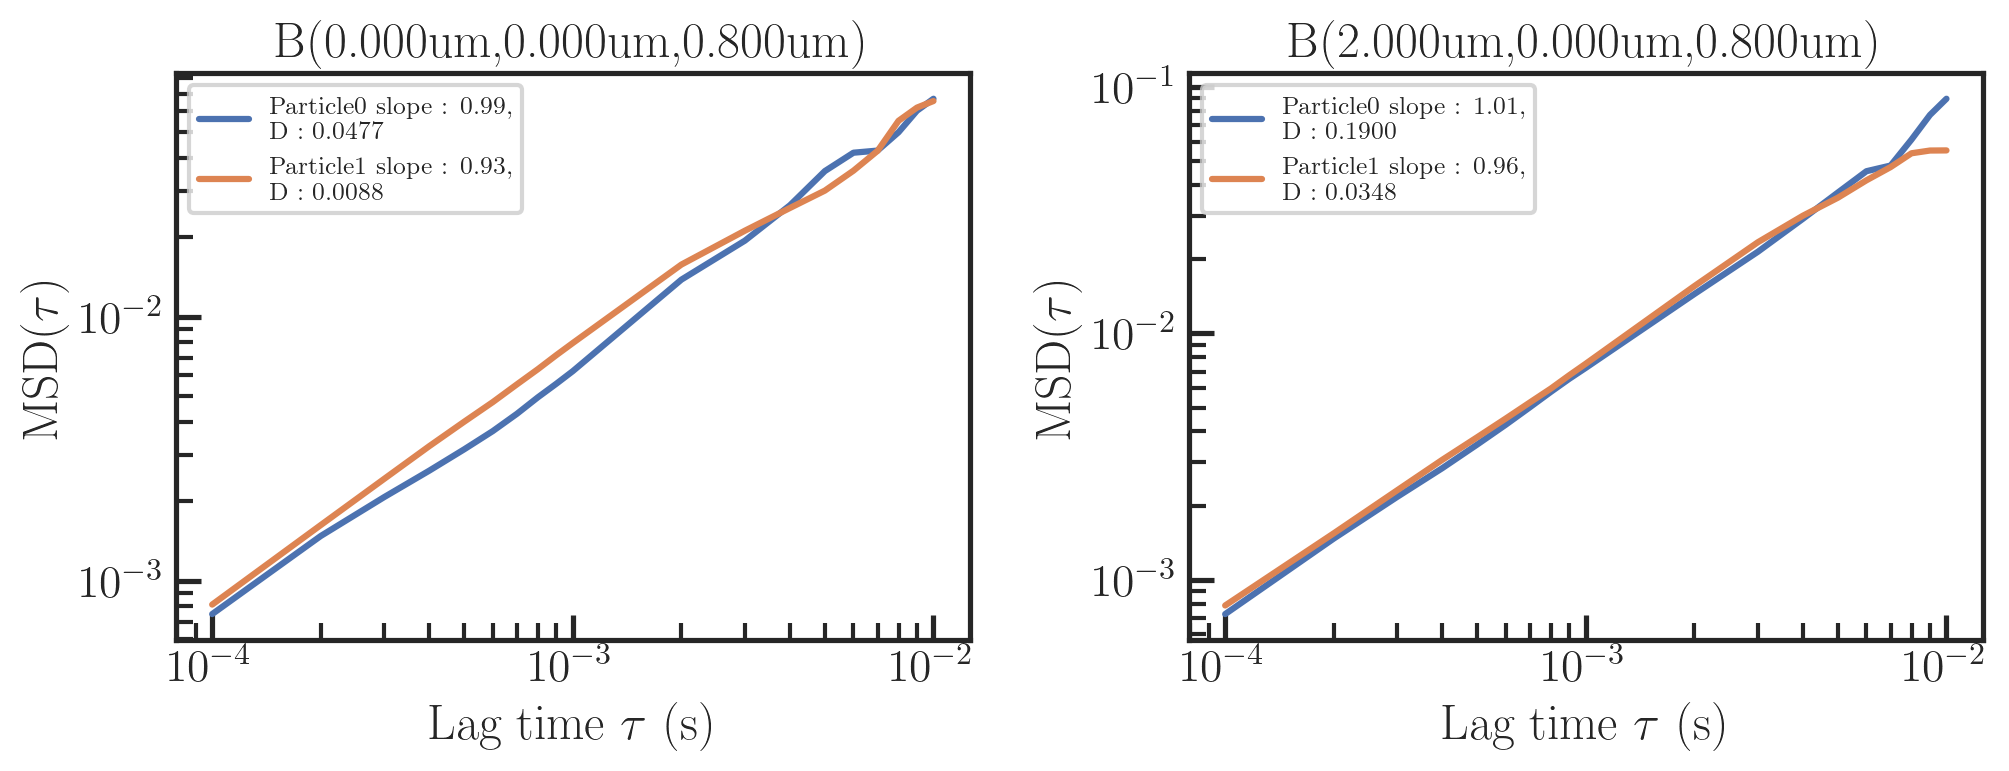

In [22]:
comp = "y"
dt = parameters.time_step

items = plot_msd_grid(
    root_dir="/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/aatwoparts_evanesce",
    comp=comp,
    dt=dt,
    ncols=2,        
    show_band=True,
    loglog=True,
    do_fit = True
)


## Correlations

In [23]:
from scipy.signal import correlate, correlation_lags

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)

    a = (a - a.mean()) / a.std()
    b = (b - b.mean()) / b.std()

    c = correlate(a, b, mode="full")
    lag_axis = correlation_lags(len(a), len(b), mode="full")
    overlap = np.minimum(len(a), len(b)) - np.abs(lag_axis)
    c = c / overlap

    return lag_axis, c


def compute_average_corr(signals_a, signals_b, comp, dt):
    xa = [get_component_signal(s, comp).astype(float) for s in signals_a]
    xb = [get_component_signal(s, comp).astype(float) for s in signals_b]
    N = min(len(xa), len(xb))
    if N == 0:
        return np.array([]), np.array([]), np.array([])

    lag_axis, c0 = corr(xa[0], xb[0])
    all_corr = [c0]

    for i in range(1, N):
        lag_i, ci = corr(xa[i], xb[i])
        if len(lag_i) == len(lag_axis) and np.all(lag_i == lag_axis):
            all_corr.append(ci)

    all_corr = np.vstack(all_corr)
    mean_corr = np.nanmean(all_corr, axis=0)
    sem_corr  = np.nanstd(all_corr, axis=0) / np.sqrt(all_corr.shape[0])

    return lag_axis * dt, mean_corr, sem_corr




In [ ]:
_B_RE = re.compile(r"__B\(([^)]+)\)$")

def extract_B_label(folder_name: str) -> str:
    m = _B_RE.search(folder_name)
    if not m:
        return folder_name
    return f"B({m.group(1).replace(' ', '')})"


def plot_corr_grid(root_dir: str, comp: str, dt: float,
                   a_prefix="A(2.500um,2.500um,0.500um)__B(",
                   ncols=3, show_band=False,
                   max_decade=8):
    root = Path(root_dir)
    candidates = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith(a_prefix)])
    if not candidates:
        raise FileNotFoundError(f"No matching folders found under: {root}")

    items = []
    for folder in candidates:
        res00_list, res01_list, res11_list = [], [], []
        for i in range(1, parameters.num_runs+1) :
            # config_path = folder / f"run_blobs.sphere_array_{i:02d}.config"
            cfg = folder / f"run_blobs.sphere_array_{i:02d}.config"

            
            frames, num_particles = parse_config(str(cfg))
            trajs = frames_to_trajectories(frames)

            sig0 = [trajs[0]]
            sig1 = [trajs[1]]

            res00_list.append(compute_average_corr(sig0, sig0, comp, dt))
            res11_list.append(compute_average_corr(sig1, sig1, comp, dt))
            res01_list.append(compute_average_corr(sig0, sig1, comp, dt))
            res00 = np.mean(res00_list, axis = 0)
            res01 = np.mean(res01_list, axis = 0)
            res11 = np.mean(res11_list, axis = 0)


        items.append((folder.name, res00, res11, res01))

    n = len(items)
    print(n)
    ncols = max(1, int(ncols))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.4 * nrows), squeeze=False)

    for k, (name, res00, res11, res01) in enumerate(items):
        r, c = divmod(k, ncols)
        ax = axes[r][c]

        t00, c00, e00 = res00
        t11, c11, e11 = res11
        t01, c01, e01 = res01

        ax.plot(t00, c00, label="Auto P0")
        ax.plot(t11, c11, label="Auto P1")
        ax.plot(t01, c01, label="Cross")

        if show_band:
            if len(e00) == len(c00): ax.fill_between(t00, c00 - e00, c00 + e00, alpha=0.2)
            if len(e11) == len(c11): ax.fill_between(t11, c11 - e11, c11 + e11, alpha=0.2)
            if len(e01) == len(c01): ax.fill_between(t01, c01 - e01, c01 + e01, alpha=0.2)

        ax.set_title(extract_B_label(name))
        ax.set_xlabel(r"$\tau$ (s)")
        ax.set_ylabel(r"$C(\tau)$")
        ax.legend(fontsize=9)

        ax.set_ylim(-1.05, 1.05)

    for k in range(n, nrows * ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis("off")

    fig.tight_layout()
    plt.show()

    return items


In [25]:
comp = "y"
dt = parameters.time_step

plot_corr_grid(
    root_dir="/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/aatwoparts_evanesce",
    comp=comp,
    dt=dt,
    ncols=6,
    show_band=False,
    max_decade=8
)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/aatwoparts_evanesce/A(2.500um,2.500um,0.500um)__B(2.000um,0.000um,0.800um)/run_blobs.sphere_array.config'